# Regressão Linear Simples — California Housing

Neste notebook, aplicamos **Regressão Linear Simples** ao dataset *California Housing*,
com **separação em treino, validação e teste** e células de Markdown para análises.

**Etapas**
1. Importar bibliotecas e carregar o dataset
2. Selecionar variável explicativa (`MedInc`) e variável alvo (`MedHouseVal`)
3. Dividir dados em **treino (60%)**, **validação (20%)** e **teste (20%)**
4. Ajustar o modelo de regressão linear simples
5. Avaliar no *validation* (MSE, R²) e depois no *test*
6. Visualizar e interpretar resultados


In [3]:
# 1) Bibliotecas
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Reprodutibilidade
RANDOM_STATE = 42

## 1. Carregar o dataset
Vamos carregar o *California Housing* via `sklearn`. O alvo é `MedHouseVal` (valor mediano das casas em centenas de milhares de dólares).

In [4]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
display(df.head())
print(f"Formato: {df.shape}")

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Formato: (20640, 9)


## 2. Regressão Linear **Simples**: escolha da variável explicativa
Usaremos apenas **`MedInc`** (renda mediana) como X, pois tipicamente apresenta alta correlação com `MedHouseVal`.

> Observação: na EDA, confirme se `MedInc` está entre os atributos mais correlacionados com o target.

In [5]:
X = df[["MedInc"]]  # variável independente
y = df["MedHouseVal"]  # variável dependente (target)
X.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001


## 3. Divisão em treino, validação e teste
Vamos dividir os dados de forma estratificada **apenas no sentido reprodutível por `random_state`** (o alvo é contínuo),
em:
- **Treino:** 60%
- **Validação:** 20%
- **Teste:** 20%

Estratégia: primeiro separamos `train` × `temp` (60/40), depois dividimos `temp` em `val` × `test` (50/50).

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)
print("Shapes:")
print("  Treino:", X_train.shape)
print("  Validação:", X_val.shape)
print("  Teste:", X_test.shape)

Shapes:
  Treino: (12384, 1)
  Validação: (4128, 1)
  Teste: (4128, 1)


## 4. Treinamento do modelo
Ajustaremos um `LinearRegression` 

**Equação do modelo**: $h(x)=\theta_0 + \theta_1 x$.

In [7]:
# Criamos o modelo de Regressão Linear (reta h(x) = θ0 + θ1 * x)
model = LinearRegression()

# Ajustamos o modelo (estimamos θ0 e θ1) usando os dados de treino
model.fit(X_train, y_train)

# O intercepto (θ0) é o ponto onde a reta cruza o eixo Y
theta0 = model.intercept_

# O coeficiente (θ1) é a inclinação da reta: indica quanto Y varia quando X aumenta em 1 unidade
theta1 = model.coef_[0]

# Exibimos os valores encontrados, formatando com 6 casas decimais
print(f"Intercepto (θ0): {theta0:.6f}")
print(f"Inclinação (θ1): {theta1:.6f}")

Intercepto (θ0): 0.440596
Inclinação (θ1): 0.419229


### Interpretação dos parâmetros do modelo

O modelo de regressão linear simples ajustado resultou nos seguintes valores:

- **Intercepto (θ0): 0.440596**  
  Esse é o valor previsto para `MedHouseVal` (valor mediano das casas, em centenas de milhares de dólares) quando a variável `MedInc` (renda mediana) é igual a 0.  
  👉 Interpretação: em regiões com renda próxima de zero, o modelo prevê um valor de aproximadamente **0.44 × 100.000 = 44.000 dólares** para as casas.

- **Inclinação (θ1): 0.419229**  
  Esse coeficiente mostra o quanto o valor mediano das casas aumenta, em média, quando a renda mediana cresce em **1 unidade** (ou seja, 1.000 dólares, já que a variável foi normalizada pelo censo).  
  👉 Interpretação: para cada aumento de 1 na renda mediana, o preço mediano das casas aumenta em aproximadamente **0.42 × 100.000 = 42.000 dólares**.

📌 Em resumo: quanto maior a renda mediana em uma região, maior tende a ser o valor mediano das casas, o que faz sentido econômico e confirma a correlação observada na EDA.

## 5. Avaliação no conjunto de **validação**
Utilizaremos **MSE** (erro quadrático médio) e **R²** (coeficiente de determinação).

### Mean Squared Error (Erro Quadrático Médio)

\begin{equation}
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
\end{equation}

Onde:

\begin{equation}
\begin{aligned}
 &\bullet y_i \quad\text{= }  \text{valor real da observação} \\
 &\bullet \hat{y}_i \quad\text{= } \text{valor previsto pelo modelo} \\
 &\bullet n \quad\text{= } \text{número total de observações} \\
\end{aligned}
\end{equation}

✅ O que é:
* É a média dos quadrados dos erros (diferença entre o valor real e o valor previsto).

* Ele está na mesma unidade do valor da variável dependente ao quadrado, então neste caso, o MSE está na ordem de milhões ao quadrado (porque o median_house_value é dado em centenas de milhares de dólares).

* Um MSE muito alto indica que as previsões estão, em média, longe dos valores reais.

* Como usamos apenas uma variável (median_income) para prever o valor da casa, é natural que o modelo não consiga capturar todos os fatores que influenciam esse valor (número de quartos, localização, idade da casa, etc.).

* Ou seja, o modelo está errando bastante em valores absolutos, mas isso é esperado em uma regressão simples.

### R² – Coeficiente de Determinação

\begin{equation}
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
\end{equation}

Onde:

\begin{equation}
\begin{aligned}
  &\bullet \bar{y} \quad\text{= } \text{média dos valores reais} \\
  &\bullet y_i \quad\text{= } \text{valor real da observação} \\
  &\bullet \hat{y}_i \quad\text{= } \text{o valor previsto pelo modelo} \\
  &\bullet n \quad\text{= } \text{número total de observações} \\
\end{aligned}
\end{equation}

✅ O que é:
* Mede quanto da variação dos dados o modelo conseguiu explicar.

* Vai de 0 (modelo não explica nada) até 1 (modelo explica tudo).

* O valor 0.452 indica que 45,2% da variação do valor das casas é explicada pela renda média da região.

* Isso já é um bom resultado para um modelo simples, considerando que usamos apenas uma variável explicativa.

* Também mostra que existem outros fatores importantes além da renda que precisam ser considerados para melhorar o modelo (o que justifica o uso de regressão múltipla depois).

In [9]:
# Usamos o modelo treinado para prever os valores de y no conjunto de validação
y_val_pred = model.predict(X_val)

# Calculamos o Erro Quadrático Médio (MSE) entre os valores reais e previstos
# Quanto menor o MSE, melhor o ajuste do modelo
mse_val = mean_squared_error(y_val, y_val_pred)

# Calculamos o coeficiente de determinação (R²)
# Mede a proporção da variância de y explicada pela variável X
# Valores próximos de 1 indicam bom ajuste; próximos de 0 indicam fraco
r2_val = r2_score(y_val, y_val_pred)

# Exibimos os resultados formatados com 6 casas decimais
print(f"MSE (validação): {mse_val:.6f}")
print(f"R²  (validação): {r2_val:.6f}")

MSE (validação): 0.714500
R²  (validação): 0.452632


In [11]:
print(y_val_pred[:10])
print(y_val[:10])

[1.43626476 1.89133779 1.74464958 1.77688828 1.37220657 2.20999372
 1.85549371 1.87297556 4.68734338 1.51663095]
5595     1.280
8046     1.866
3798     2.094
6659     1.731
9567     0.750
6954     1.780
19415    2.125
11674    1.872
10317    4.543
17444    2.393
Name: MedHouseVal, dtype: float64


### Interpretação dos resultados de validação

- **MSE (validação): 0.714500**  
  O erro quadrático médio indica que, em média, a diferença entre os valores previstos e os valores reais é da ordem de **0.71** (em unidades do target `MedHouseVal`, ou seja, centenas de milhares de dólares).  
  👉 Isso significa que o modelo erra, em média, cerca de **71 mil dólares** ao prever o valor mediano das casas.

- **R² (validação): 0.452632**  
  O coeficiente de determinação mostra que aproximadamente **45% da variabilidade** do valor das casas pode ser explicada apenas pela variável `MedInc` (renda mediana).  
  👉 Embora o valor seja razoável, ele também indica que **55% da variabilidade** ainda não é capturada — o que é esperado, já que estamos usando apenas **uma variável** para explicar um fenômeno complexo.

📌 **Resumo:**  
O modelo com uma única variável (`MedInc`) consegue capturar parte importante da relação entre renda e valor das casas, mas não é suficiente para explicar toda a variabilidade. Para melhorar, precisaríamos incluir mais variáveis preditoras (regressão múltipla).


## 6. Avaliação final no **teste**
Após checar o desempenho no *validation*, avaliamos no *test* para uma estimativa final de generalização.

In [12]:
y_test_pred = model.predict(X_test)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
print(f"MSE (teste): {mse_test:.6f}")
print(f"R²  (teste): {r2_test:.6f}")

MSE (teste): 0.702809
R²  (teste): 0.487422


### Interpretação dos resultados no conjunto de teste

- **MSE (teste): 0.702809**  
  O erro quadrático médio foi levemente menor que no conjunto de validação (0.714500 → 0.702809).  
  👉 Isso indica que o modelo manteve um nível de erro parecido ao prever novos dados, o que sugere boa **generalização**.  
  Em termos práticos, o erro médio nas previsões é de aproximadamente **70 mil dólares**.

- **R² (teste): 0.487422**  
  O modelo conseguiu explicar cerca de **48,7% da variabilidade** do valor das casas no conjunto de teste.  
  👉 O resultado é até um pouco melhor que no conjunto de validação (45,2%), reforçando que o modelo não sofreu overfitting relevante.

📌 **Resumo:**  
O desempenho no teste confirma que a variável `MedInc` (renda mediana) é um bom preditor do valor das casas, explicando quase metade da variação.  
Ainda assim, mais variáveis precisariam ser incluídas em um modelo de **regressão múltipla** para capturar maior parte da complexidade dos dados.

## 7. Visualização
Vamos visualizar a **reta de regressão** sobre os pontos de teste. Usamos `matplotlib` e uma amostra para deixar o gráfico legível.

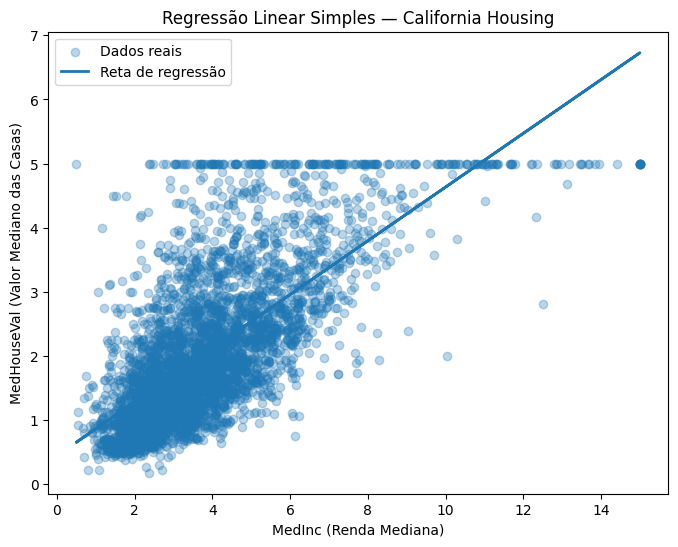

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, alpha=0.3, label="Dados reais")
plt.plot(X_test, y_test_pred, linewidth=2, label="Reta de regressão")
plt.xlabel("MedInc (Renda Mediana)")
plt.ylabel("MedHouseVal (Valor Mediano das Casas)")
plt.title("Regressão Linear Simples — California Housing")
plt.legend()
plt.show()

## 8. Interpretação e comentários
- **Sinal de θ1**: positivo costuma indicar que casas em regiões com maior renda mediana tendem a ter maior valor mediano.
- **Magnitude do R²**: indica a fração da variância de `MedHouseVal` explicada por `MedInc`.
- **Limitação**: por ser *simples* (apenas 1 variável), o modelo não captura toda a complexidade do problema.
- **Próximos passos**: experimentar regressão **múltipla** com mais atributos; normalização/transformações; validação cruzada.

# Tarefas — Atividade 3 (Moodle)

📌 Este notebook deve ser entregue no Moodle em:  
**Atividade 3 - Regressão Linear Simples**

Realize as análises abaixo. Cada tarefa deve conter:

- **Código em Python** para gerar o resultado.  
- **Markdown explicativo** abaixo do código, comentando os gráficos ou valores obtidos.  

## 1. **Experimente outra variável independente**  
   - Repita o processo de regressão linear simples usando `AveRooms` ou `Latitude` como variável explicativa.  
   - Compare os valores de MSE e R² com os obtidos usando `MedInc`.  
   - Pergunta: Qual variável foi um preditor melhor?

---

In [ ]:
# === Regressão Linear Simples usando AveRooms (mesmos conjuntos já prontos) ===

# Substituímos a coluna usada (MedInc) pela nova (AveRooms)
X_train_ar = df.loc[X_train.index, ["AveRooms"]]
X_val_ar   = df.loc[X_val.index,   ["AveRooms"]]
X_test_ar  = df.loc[X_test.index,  ["AveRooms"]]

y_train_ar = y_train
y_val_ar   = y_val
y_test_ar  = y_test

In [ ]:
# Treina o modelo


In [ ]:
# Avaliação no conjunto de validação


### Resultados de validação — AveRooms

- **MSE (validação):**  
  
- **R² (validação):**  

📌 **Resumo:**  

In [1]:
# Avaliação no conjunto de teste


### Resultados de teste — AveRooms

- **MSE (teste):**  

- **R² (teste):**  

📌 **Resumo:**  


## 2. **Visualize a reta no conjunto de treino**  
   - Gere um gráfico de dispersão dos dados de treino (`X_train` × `y_train`).  
   - Adicione a reta de regressão estimada.  
   - Pergunta: A reta parece representar bem os dados?

---

In [ ]:
# Dispersão do conjunto de TREINO + reta ajustada (AveRooms)



## Comentários sobre o gráfico — AveRooms

- 1 
- 2 
- ...
  
📌 **Resumo:**

## 3. **Reflexão crítica**  
   - Por que uma única variável não é suficiente para explicar todo o valor das casas?  
   - Que outras variáveis do dataset você incluiria em um modelo de regressão múltipla?  

## Reflexão crítica

- **Por que uma única variável não é suficiente?**  
  
- **Quais variáveis poderiam ser incluídas em uma regressão múltipla?**  
  
📌 **Resumo:**  